<a href="https://colab.research.google.com/github/creydit/Stock-Portfolio-Management/blob/main/Sentiment_Analysis_Stock_Portfolio_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>








# 📈 Stock Portfolio Management with Sentiment Analysis


# ⚙️ Install Required Libraries

In [97]:
!pip install yfinance pandas numpy matplotlib requests beautifulsoup4 vaderSentiment textblob afinn transformers torch lxml --quiet
!pip install hf_xet
!pip install huggingface_hub[hf_xet]

# 🧩 Import Libraries

In [98]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import datetime
from textblob import TextBlob
from afinn import Afinn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm.notebook import tqdm
import contextlib
import io
import logging
from datetime import datetime
import urllib.parse
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

# 🧠 Generating Portolio From User Inputs

In [99]:
def is_valid_ticker(ticker_symbol):
  """Checks if a ticker exists on Yahoo Finance while suppressing internal error logs."""
  try:
    f = io.StringIO()
    with contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
      stock = yf.Ticker(ticker_symbol)
      history = stock.history(period='1d')
      return not history.empty
  except Exception:
    return False


user_portfolio = {}

print('📥 --- Portfolio Setup ---')
print(
    'Enter stock tickers and their percentage allocation (e.g., enter 20 for'
    ' 20%).'
)
print("Type 'done' when you are finished.\n")

while True:
  current_total = sum(user_portfolio.values())
  remaining = 100.0 - current_total

  # 1. Take raw user input
  raw_input = input("Enter Ticker (e.g., NVDA, AMZN) or 'done': ").strip()

  # 2. Check for empty input
  if not raw_input:
    print('⚠️ Input cannot be empty! Please enter a stock ticker or "done".')
    continue

  # 3. Check for 'done'
  if raw_input.lower() == 'done':
    if len(user_portfolio) == 0:
      print('⚠️ You must enter at least one stock ticker before finishing!')
      continue

    if current_total < 100.0:
      print(f'\n⚠️ Total allocated is only {current_total:.1f}% (less than 100%).')
      confirm = (
          input(
              'Do you want to stop and automatically scale your stocks to sum'
              ' to 100%? (y/n): '
          )
          .strip()
          .lower()
      )
      if confirm != 'y':
        continue
    break

  ticker = raw_input.upper()

  # 4. Check for duplicates
  if ticker in user_portfolio:
    print(
        f'⚠️ {ticker} is already in your portfolio ({user_portfolio[ticker]}%).'
    )
    override = (
        input(f'Do you want to re-enter the percentage for {ticker}? (y/n): ')
        .strip()
        .lower()
    )
    if override == 'y':
      current_total -= user_portfolio[ticker]
      del user_portfolio[ticker]
      remaining = 100.0 - current_total
    else:
      continue

  # 5. Validate ticker existence
  print(f"🔍 Validating ticker '{ticker}'...")
  if not is_valid_ticker(ticker):
    print(
        f"❌ Error: '{ticker}' is not a valid or active stock ticker symbol."
        ' Please try again.\n'
    )
    continue
  print(f"✅ '{ticker}' verified!")

  # 6. Take weight input
  try:
    weight = float(
        input(
            f'Enter percentage for {ticker} (Remaining available:'
            f' {remaining:.1f}%): '
        )
    )

    if weight <= 0:
      print('⚠️ Percentage must be greater than 0.')
      continue

    if current_total + weight > 100.0 + 1e-5:
      print(
          f'⚠️ Error: Adding {weight}% exceeds 100%! You only have'
          f' {remaining:.1f}% left to allocate.'
      )
      continue

    user_portfolio[ticker] = weight
    current_total += weight
    print(
        f'  ➜ Added {ticker}: {weight:.1f}% | Total Allocated:'
        f' {current_total:.1f}%\n'
    )

    if abs(current_total - 100.0) < 1e-5:
      print('🎉 Portfolio allocation reached 100%! Stopping automatically.')
      break

  except ValueError:
    print('⚠️ Invalid input! Please enter a numeric percentage.')

# Normalize user weights to decimals (summing to 1.0)
tickers = list(user_portfolio.keys())
raw_weights = np.array(list(user_portfolio.values()))
initial_weights = raw_weights / raw_weights.sum()

print('\n✅ Final Portfolio Baseline:')
print('--------------------------')
for t, w in zip(tickers, initial_weights):
  print(f'  • {t}: {w:.2%}')

📥 --- Portfolio Setup ---
Enter stock tickers and their percentage allocation (e.g., enter 20 for 20%).
Type 'done' when you are finished.

Enter Ticker (e.g., NVDA, AMZN) or 'done': NVDA
🔍 Validating ticker 'NVDA'...
✅ 'NVDA' verified!
Enter percentage for NVDA (Remaining available: 100.0%): 20
  ➜ Added NVDA: 20.0% | Total Allocated: 20.0%

Enter Ticker (e.g., NVDA, AMZN) or 'done': AMZN
🔍 Validating ticker 'AMZN'...
✅ 'AMZN' verified!
Enter percentage for AMZN (Remaining available: 80.0%): 20
  ➜ Added AMZN: 20.0% | Total Allocated: 40.0%

Enter Ticker (e.g., NVDA, AMZN) or 'done': GOOGL
🔍 Validating ticker 'GOOGL'...
✅ 'GOOGL' verified!
Enter percentage for GOOGL (Remaining available: 60.0%): 20
  ➜ Added GOOGL: 20.0% | Total Allocated: 60.0%

Enter Ticker (e.g., NVDA, AMZN) or 'done': MSFT
🔍 Validating ticker 'MSFT'...
✅ 'MSFT' verified!
Enter percentage for MSFT (Remaining available: 40.0%): 30
  ➜ Added MSFT: 30.0% | Total Allocated: 90.0%

Enter Ticker (e.g., NVDA, AMZN) or 'do

# 📰 Scrape News

In [100]:

def get_finviz_news(ticker):
  url = f'https://finviz.com/quote.ashx?t={ticker}'
  headers = {'User-Agent': 'Mozilla/5.0'}
  try:
    html = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(html.text, 'lxml')
    news_table = soup.find(id='news-table')
    if not news_table:
      return []

    rows = news_table.find_all('tr')
    news = []
    for row in rows:
      title = row.a.text.strip() if row.a else None
      time_text = row.td.text.strip()
      if title:
        news.append([ticker, time_text, title])
    return news
  except Exception as e:
    print(f'⚠️ Finviz error for {ticker}: {e}')
    return []


def get_google_news(ticker):
  # Strips exchange suffixes (e.g., '.NS', '.BO') for a cleaner search query
  clean_symbol = ticker.split('.')[0]
  query = urllib.parse.quote(f'{clean_symbol} stock news')
  url = f'https://news.google.com/rss/search?q={query}&hl=en&gl=US&ceid=US:en'

  headers = {'User-Agent': 'Mozilla/5.0'}
  try:
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.content, 'xml')
    items = soup.find_all('item')
    news = []

    for item in items:
      title = item.title.text if item.title else None
      time_text = item.pubDate.text if item.pubDate else None
      if title:
        # Clean up source tag attached by Google (e.g., "Stock Soars - Source" -> "Stock Soars")
        clean_title = title.split(' - ')[0].strip()
        news.append([ticker, time_text, clean_title])
    return news
  except Exception as e:
    print(f'⚠️ Google News error for {ticker}: {e}')
    return []


# ==========================================
# FETCH COMBINED HEADLINES
# ==========================================
all_news = []

for ticker in tickers:
  print(f'🔍 Fetching news for {ticker}...')

  finviz_data = get_finviz_news(ticker)
  google_data = get_google_news(ticker)

  print(
      f'   • Finviz: {len(finviz_data)} headlines | Google News:'
      f' {len(google_data)} headlines'
  )

  all_news.extend(finviz_data)
  all_news.extend(google_data)

# Create DataFrame
news_df = pd.DataFrame(all_news, columns=['ticker', 'datetime', 'headline'])

# Drop exact duplicate headlines per ticker
news_df = news_df.drop_duplicates(subset=['ticker', 'headline']).reset_index(
    drop=True
)

print(f'\n✅ Total Unique Headlines Collected: {len(news_df)}')
display(news_df.head())

🔍 Fetching news for NVDA...
   • Finviz: 100 headlines | Google News: 100 headlines
🔍 Fetching news for AMZN...
   • Finviz: 100 headlines | Google News: 100 headlines
🔍 Fetching news for GOOGL...
   • Finviz: 100 headlines | Google News: 102 headlines
🔍 Fetching news for MSFT...
   • Finviz: 0 headlines | Google News: 100 headlines
🔍 Fetching news for SPCX...
   • Finviz: 0 headlines | Google News: 100 headlines

✅ Total Unique Headlines Collected: 776


,ticker,datetime,headline
0,NVDA,Today 03:48AM,Samsung and SK Hynix unveil $950 billion US ch...
1,NVDA,01:10AM,SK Group and NVIDIA Expand Strategic Partnersh...
2,NVDA,01:10AM,"NAVER, NVIDIA and Brookfield to Expand Korea's..."
3,NVDA,12:37AM,"South Korea's SK Hynix, Samsung Elec sign $950..."
4,NVDA,12:34AM,"Samsung, SK, Hyundai join Jensen Huang and Kor..."


# 💬 Sentiment Analysis using VADER

In [101]:
#Sentiment Scores using VADER = Valence Aware Dictionary for sEntiment Reasoning
analyzer = SentimentIntensityAnalyzer()
news_df['sentiment'] = news_df['headline'].apply(lambda x: analyzer.polarity_scores(x)['compound'] if isinstance(x, str) else 0)
sentiment_scores_VADER = news_df.groupby('ticker')['sentiment'].mean()
print('Average Sentiment per Stock:')
print(sentiment_scores_VADER)

Average Sentiment per Stock:
ticker
AMZN     0.135966
GOOGL    0.015670
MSFT     0.127039
NVDA     0.084795
SPCX     0.035763
Name: sentiment, dtype: float64


# 💬 Sentiment Analysis using TextBlob

In [102]:
#Sentiment Scores using TextBlob
def textblob_score(x):
    return TextBlob(x).sentiment.polarity if isinstance(x, str) else 0

news_df['sentiment_textblob'] = news_df['headline'].apply(textblob_score)

sentiment_scores_TextBlob = news_df.groupby('ticker')['sentiment_textblob'].mean()
print("Average TextBlob Sentiment per Stock:")
print(sentiment_scores_TextBlob)

Average TextBlob Sentiment per Stock:
ticker
AMZN     0.090733
GOOGL    0.057522
MSFT     0.172996
NVDA     0.067534
SPCX     0.028083
Name: sentiment_textblob, dtype: float64


# 💬 Sentiment Analysis using AFINN

In [103]:
#Sentiment Scores using AFINN
af = Afinn()

def afinn_score(x):
    if isinstance(x, str):
        raw = af.score(x)           # raw score can be any number
        return float(np.tanh(raw/5))  # normalize to -1..1
    return 0

news_df['sentiment_afinn'] = news_df['headline'].apply(afinn_score)

sentiment_scores_AFINN = news_df.groupby('ticker')['sentiment_afinn'].mean()
print("Average AFINN Sentiment per Stock:")
print(sentiment_scores_AFINN)

Average AFINN Sentiment per Stock:
ticker
AMZN     0.045863
GOOGL    0.006068
MSFT     0.092634
NVDA     0.070006
SPCX     0.030922
Name: sentiment_afinn, dtype: float64


# 💬 Sentiment Analysis using FinBERT

In [104]:
#Sentiment Scores using FinBERT
print("🤖 Loading FinBERT Transformer model...")
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


def get_finbert_score(text):
  if not isinstance(text, str) or not text.strip():
    return 0.0

  inputs = tokenizer(
      text, return_tensors="pt", truncation=True, max_length=128, padding=True
  ).to(device)
  with torch.no_grad():
    outputs = model(**inputs)
    probs = (
        torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()
    )

  # FinBERT output order: [positive, negative, neutral]
  pos, neg = probs[0], probs[1]
  return float(pos - neg)  # Score between -1 and 1


print("💬 Scoring headlines with FinBERT...")
tqdm.pandas(desc="FinBERT Sentiment")
news_df["sentiment_finbert"] = news_df["headline"].progress_apply(
    get_finbert_score
)

# Compute mean score per ticker aligned with our portfolio
sentiment_scores_FinBERT = (
    news_df.groupby("ticker")["sentiment_finbert"]
    .mean()
    .reindex(tickers)
    .fillna(0)
)
print("\n📊 Average FinBERT Sentiment per Stock:")
print(sentiment_scores_FinBERT)

🤖 Loading FinBERT Transformer model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

💬 Scoring headlines with FinBERT...


FinBERT Sentiment:   0%|          | 0/776 [00:00<?, ?it/s]


📊 Average FinBERT Sentiment per Stock:
ticker
NVDA     0.014635
AMZN    -0.173883
GOOGL   -0.309284
MSFT    -0.059722
SPCX    -0.390073
Name: sentiment_finbert, dtype: float64


#💬 Sentiment Analysis using Custom Analyzer "ReyZer"

In [105]:
#Training Custom Sentiment Analyzer "ReyZer"
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# ==========================================
# 1. LOAD & PREPARE DATASET ("ReyZer")
# ==========================================
print("⏳ Loading Financial PhraseBank dataset (Parquet format)...")

# Load parquet-native version (no python loading scripts)
raw_dataset = load_dataset("atrost/financial_phrasebank")

# Combine splits (train/validation/test) into one dataframe 'ReyZer'
df_train = pd.DataFrame(raw_dataset["train"])
df_val = (
    pd.DataFrame(raw_dataset["validation"])
    if "validation" in raw_dataset
    else pd.DataFrame()
)
df_test = (
    pd.DataFrame(raw_dataset["test"])
    if "test" in raw_dataset
    else pd.DataFrame()
)

ReyZer = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Standardize column name ('sentence' -> 'headline')
if "sentence" in ReyZer.columns:
  ReyZer = ReyZer.rename(columns={"sentence": "headline"})

print(f"✅ Dataset 'ReyZer' successfully loaded with {len(ReyZer)} rows!")

# ==========================================
# 2. SPLIT DATA (TRAIN / TEST)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    ReyZer["headline"],
    ReyZer["label"],
    test_size=0.2,
    random_state=42,
    stratify=ReyZer["label"],
)

# ==========================================
# 3. TF-IDF VECTORIZATION
# ==========================================
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), max_features=5000, stop_words="english"
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ==========================================
# 4. TRAIN LOGISTIC REGRESSION CLASSIFIER
# ==========================================
custom_classifier = LogisticRegression(C=1.0, max_iter=1000)
custom_classifier.fit(X_train_tfidf, y_train)

# ==========================================
# 5. EVALUATE MODEL PERFORMANCE
# ==========================================
y_pred = custom_classifier.predict(X_test_tfidf)
print("\n=== Custom Model Performance Report ===")
print(
    classification_report(
        y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]
    )
)


# ==========================================
# 6. SCORING FUNCTION FOR PORTFOLIO PIPELINE
# ==========================================
def get_custom_tfidf_sentiment(headline):
  if not isinstance(headline, str) or not headline.strip():
    return 0.0
  vec = vectorizer.transform([headline])
  probs = custom_classifier.predict_proba(vec)[0]  # [Negative, Neutral, Positive]
  return float(probs[2] - probs[0])  # Continuous sentiment score (-1.0 to +1.0)

⏳ Loading Financial PhraseBank dataset (Parquet format)...
✅ Dataset 'ReyZer' successfully loaded with 4846 rows!

=== Custom Model Performance Report ===
              precision    recall  f1-score   support

    Negative       0.80      0.32      0.46       121
     Neutral       0.74      0.93      0.83       576
    Positive       0.67      0.49      0.57       273

    accuracy                           0.73       970
   macro avg       0.74      0.58      0.62       970
weighted avg       0.73      0.73      0.71       970



In [106]:
#Sentiment Analaysis using ReyZer
# Link function if named get_custom_tfidf_sentiment
if (
    'get_reyzer_sentiment' not in globals()
    and 'get_custom_tfidf_sentiment' in globals()
):
  get_reyzer_sentiment = get_custom_tfidf_sentiment

print("⏳ Scoring headlines using ReyZer model...")
news_df["sentiment_ReyZer"] = news_df["headline"].apply(get_reyzer_sentiment)

sentiment_scores_ReyZer = (
    news_df.groupby("ticker")["sentiment_ReyZer"].mean().to_dict()
)

print("\n📊 Average ReyZer Sentiment Score per Stock:")
for ticker, score in sentiment_scores_ReyZer.items():
  print(f"   • {ticker:<10}: {score:>+.4f}")

⏳ Scoring headlines using ReyZer model...

📊 Average ReyZer Sentiment Score per Stock:
   • AMZN      : +0.1425
   • GOOGL     : +0.1611
   • MSFT      : +0.1762
   • NVDA      : +0.1771
   • SPCX      : +0.1362


# 💹 Fetch Historical Stock Data

In [107]:
data = yf.download(tickers, start='2026-01-01', end='2026-07-24')['Close']
returns = data.pct_change().dropna()
mean_returns = returns.mean() * 252                # 252 Trading Days Per Year
cov_matrix = returns.cov() * 252

/tmp/ipykernel_515/167135748.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2026-01-01', end='2026-07-24')['Close']
[*********************100%***********************]  5 of 5 completed


# 📈 Base Portfolio From Past Data

In [108]:
port_return_base = np.dot(initial_weights, mean_returns)
port_volatility_base = np.sqrt(np.dot(initial_weights.T, np.dot(cov_matrix, initial_weights)))
sharpe_base = port_return_base / port_volatility_base if port_volatility_base > 0 else 0

print("==========================================================================")
print("                           PORTFOLIO SUMMARY                              ")
print("==========================================================================")
print(f"📊 Baseline User Portfolio  | Return: {port_return_base:>7.2%} | Risk: {port_volatility_base:>7.2%} | Sharpe: {sharpe_base:.2f}")
print("-" * 74)

                           PORTFOLIO SUMMARY                              
📊 Baseline User Portfolio  | Return: -43.71% | Risk:  30.22% | Sharpe: -1.45
--------------------------------------------------------------------------


# 🧠 Sentiment Adjusted Portfolio

In [109]:
sentiment_dict = {
    "FinBERT": sentiment_scores_FinBERT,
    "VADER": sentiment_scores_VADER,
    "TextBlob": sentiment_scores_TextBlob,
    "AFINN": sentiment_scores_AFINN,
    "ReyZer": sentiment_scores_ReyZer,
}

gamma = 0.5  # Sensitivity hyperparameter (controls sentiment weight tilt)

adjusted_portfolio_weights = {}

for model_name, scores in sentiment_dict.items():
    # Align scores array with ticker order
    s_values = np.array([scores.get(t, 0.0) for t in tickers])

    # Formula: w_i_adjusted = w_i_initial * (1 + gamma * score_i)
    raw_weights = initial_weights * (1 + gamma * s_values)

    # Ensure no negative weights
    raw_weights = np.maximum(raw_weights, 0)

    # Re-normalize so weights sum to 100% (1.0)
    adj_weights = raw_weights / raw_weights.sum()
    adjusted_portfolio_weights[model_name] = adj_weights

    # Calculate performance for this sentiment model
    port_return_adj = np.dot(adj_weights, mean_returns)
    port_volatility_adj = np.sqrt(np.dot(adj_weights.T, np.dot(cov_matrix, adj_weights)))
    sharpe_adj = port_return_adj / port_volatility_adj if port_volatility_adj > 0 else 0

    print(f"🧠 {model_name:<10} Adjusted   | Return: {port_return_adj:>7.2%} | Risk: {port_volatility_adj:>7.2%} | Sharpe: {sharpe_adj:.2f}")

print("==========================================================================")

🧠 FinBERT    Adjusted   | Return: -40.07% | Risk:  29.72% | Sharpe: -1.35
🧠 VADER      Adjusted   | Return: -43.36% | Risk:  30.15% | Sharpe: -1.44
🧠 TextBlob   Adjusted   | Return: -42.52% | Risk:  30.03% | Sharpe: -1.42
🧠 AFINN      Adjusted   | Return: -43.16% | Risk:  30.17% | Sharpe: -1.43
🧠 ReyZer     Adjusted   | Return: -43.20% | Risk:  30.14% | Sharpe: -1.43


# 📊 Visualization

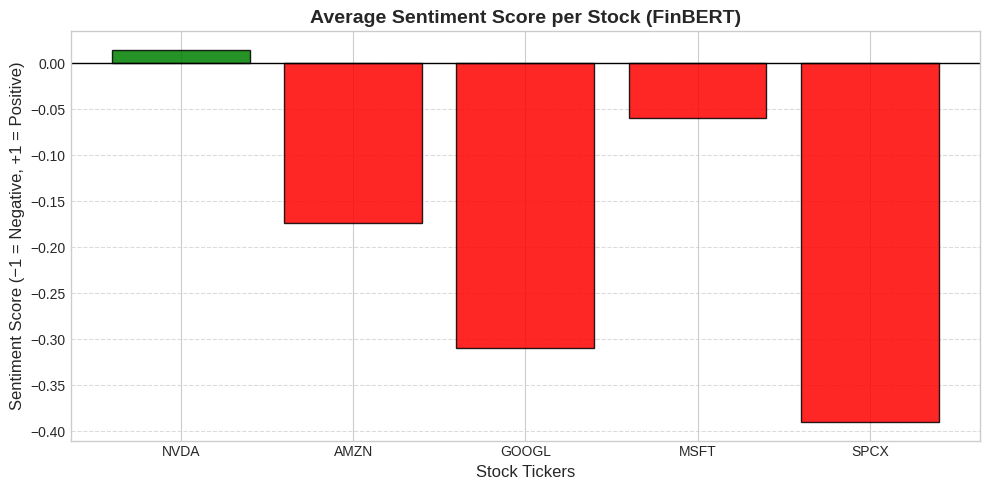

In [110]:
# ==========================================
# CHOOSE MODEL FOR VISUALIZATION
# Options: 'FinBERT', 'VADER', 'TextBlob', 'AFINN', 'ReyZer'
# ==========================================
selected_model = 'FinBERT'

# Get scores for the selected model
scores_series = sentiment_dict[selected_model]
scores_aligned = [scores_series.get(t, 0.0) for t in tickers]

# Plot Setup
plt.figure(figsize=(10, 5))
colors = ['red' if s < 0 else 'green' for s in scores_aligned]

plt.bar(tickers, scores_aligned, color=colors, edgecolor='black', alpha=0.85)

# Formatting
plt.title(
    f'Average Sentiment Score per Stock ({selected_model})',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Stock Tickers', fontsize=12)
plt.ylabel('Sentiment Score (−1 = Negative, +1 = Positive)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

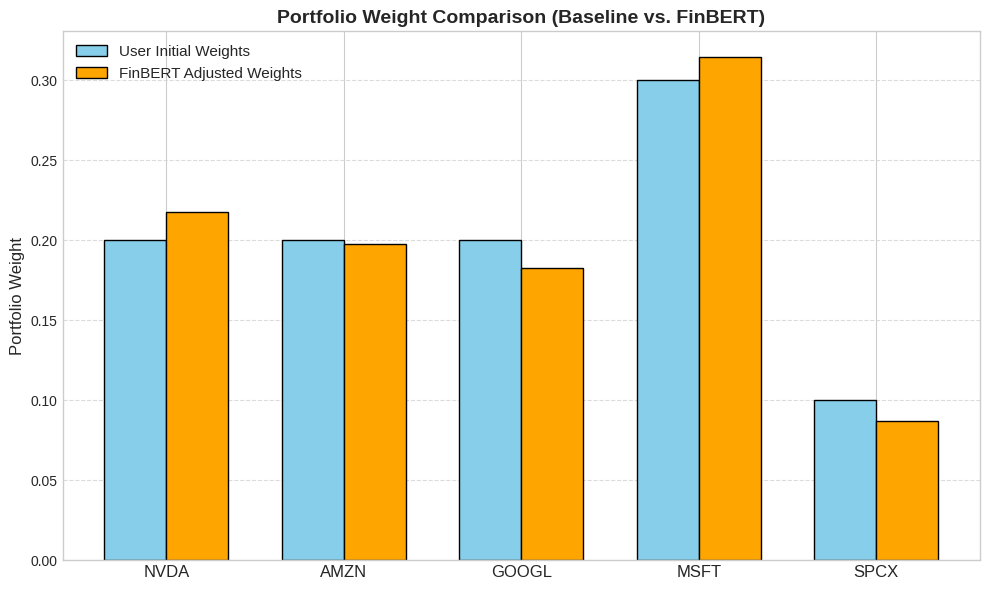

In [111]:
# ==========================================
# CHOOSE MODEL FOR WEIGHT COMPARISON
# Options: 'FinBERT', 'VADER', 'TextBlob', 'AFINN', 'ReyZer'
# ==========================================
selected_model = 'FinBERT'

# Get adjusted weights for the chosen model
model_weights = adjusted_portfolio_weights[selected_model]

# Plot Setup
x = np.arange(len(tickers))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Side-by-side bars
ax.bar(
    x - width / 2,
    initial_weights,
    width,
    label='User Initial Weights',
    color='skyblue',
    edgecolor='black',
)
ax.bar(
    x + width / 2,
    model_weights,
    width,
    label=f'{selected_model} Adjusted Weights',
    color='orange',
    edgecolor='black',
)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(tickers, fontsize=12)
ax.set_ylabel('Portfolio Weight', fontsize=12)
ax.set_title(
    f'Portfolio Weight Comparison (Baseline vs. {selected_model})',
    fontsize=14,
    fontweight='bold',
)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#⌛Overall Conclusion Custom Made Model (ReyZer), FinBERT, VADER, TextBlob and AFINN Ensembled Into One

In [112]:
sentiment_scores_Ensemble = {}

for ticker in tickers:
  fb = sentiment_scores_FinBERT.get(ticker, 0.0)
  rz = sentiment_scores_ReyZer.get(ticker, 0.0)
  vd = sentiment_scores_VADER.get(ticker, 0.0)
  tb = sentiment_scores_TextBlob.get(ticker, 0.0)

  # Consensus weights: 35% FinBERT, 35% ReyZer, 15% VADER, 15% TextBlob
  ensemble_score = (0.35 * fb) + (0.35 * rz) + (0.15 * vd) + (0.15 * tb)
  sentiment_scores_Ensemble[ticker] = ensemble_score

# Compute Ensemble Weights & Metrics
ens_s_values = np.array([sentiment_scores_Ensemble.get(t, 0.0) for t in tickers])
ens_raw_weights = initial_weights * (1 + gamma * ens_s_values)
ens_raw_weights = np.maximum(ens_raw_weights, 0)
ens_adj_weights = ens_raw_weights / ens_raw_weights.sum()

# Save into weights dict for separate visualization if needed
adjusted_portfolio_weights["Ensemble_Combined"] = ens_adj_weights

# Final Ensemble Calculations
ens_return = np.dot(ens_adj_weights, mean_returns)
ens_volatility = np.sqrt(
    np.dot(ens_adj_weights.T, np.dot(cov_matrix, ens_adj_weights))
)
ens_sharpe = ens_return / ens_volatility if ens_volatility > 0 else 0

# Print Standalone Final Ensemble Output
print(
    "\n=========================================================================="
)
print(
    "                  🏆 COMBINED ENSEMBLE PORTFOLIO RETURNS                   "
)
print(
    "=========================================================================="
)
print(
    f"⭐ Combined Ensemble Model  | Return: {ens_return:>7.2%} | Risk:"
    f" {ens_volatility:>7.2%} | Sharpe: {ens_sharpe:.2f}"
)
print(
    "=========================================================================="
)


                  🏆 COMBINED ENSEMBLE PORTFOLIO RETURNS                   
⭐ Combined Ensemble Model  | Return: -42.12% | Risk:  29.99% | Sharpe: -1.40


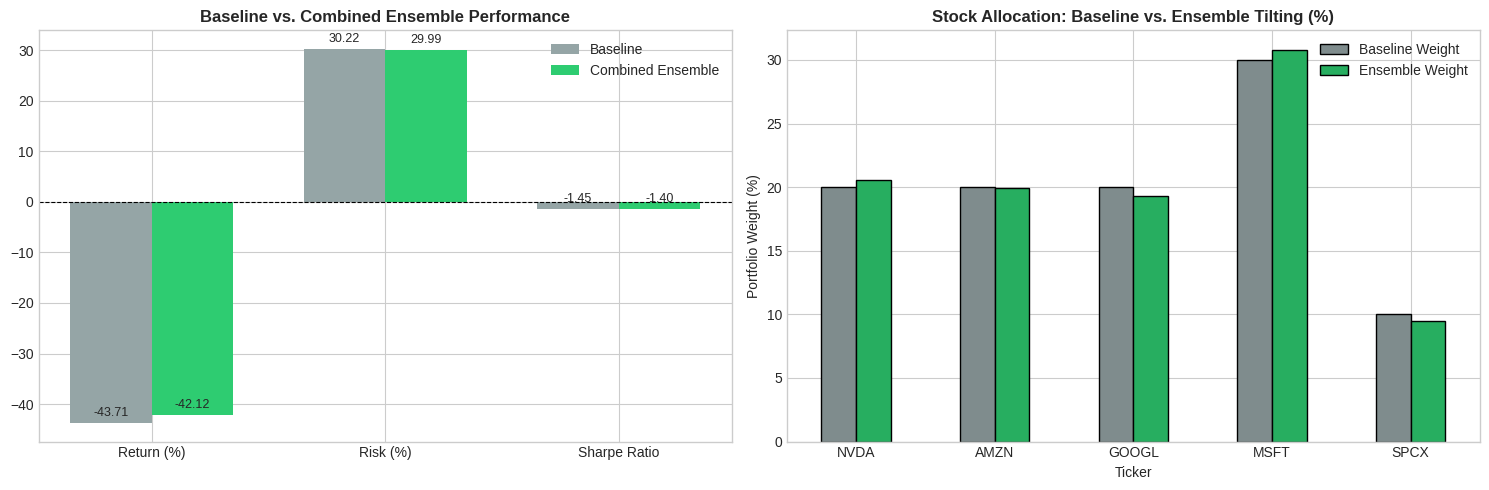

In [113]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ==========================================
# 1. PERFORMANCE COMPARISON DATA
# ==========================================
perf_comparison = pd.DataFrame({
    "Metric": ["Return (%)", "Risk (%)", "Sharpe Ratio"],
    "Baseline Portfolio": [
        port_return_base * 100,
        port_volatility_base * 100,
        sharpe_base,
    ],
    "Ensemble Portfolio": [
        ens_return * 100,
        ens_volatility * 100,
        ens_sharpe,
    ],
})

# ==========================================
# PLOT 1: BASELINE VS ENSEMBLE METRICS
# ==========================================
x = np.arange(len(perf_comparison))
width = 0.35

rects1 = axes[0].bar(
    x - width / 2,
    perf_comparison["Baseline Portfolio"],
    width,
    label="Baseline",
    color="#95a5a6",
)
rects2 = axes[0].bar(
    x + width / 2,
    perf_comparison["Ensemble Portfolio"],
    width,
    label="Combined Ensemble",
    color="#2ecc71",
)

axes[0].set_title(
    "Baseline vs. Combined Ensemble Performance",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(perf_comparison["Metric"], fontsize=10)
axes[0].legend()
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")

# Add data values on top of bars
for rect in rects1 + rects2:
  height = rect.get_height()
  axes[0].annotate(
      f"{height:.2f}",
      xy=(rect.get_x() + rect.get_width() / 2, height),
      xytext=(0, 3),
      textcoords="offset points",
      ha="center",
      va="bottom",
      fontsize=9,
  )

# ==========================================
# PLOT 2: WEIGHT ALLOCATION SHIFT PER TICKER
# ==========================================
weight_df = pd.DataFrame({
    "Baseline Weight": initial_weights * 100,
    "Ensemble Weight": ens_adj_weights * 100,
}, index=tickers)

weight_df.plot(
    kind="bar", ax=axes[1], color=["#7f8c8d", "#27ae60"], edgecolor="black"
)

axes[1].set_title(
    "Stock Allocation: Baseline vs. Ensemble Tilting (%)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_ylabel("Portfolio Weight (%)", fontsize=10)
axes[1].set_xlabel("Ticker", fontsize=10)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()